# Análises de Desproporcionalidade – Projeto Vigimed 🇧🇷
# Analysis of Disproportionality – Vigimed Project

PT: Este notebook implementa cálculos de ROR, PRR, IC (BCPNN) e EBGM (MGPS) utilizando um banco de dados padronizado, construído a partir de dados abertos oficiais do Brasil (Vigimed) e codificado com MedDRA e ATC. O objetivo é permitir a reprodução das análises e facilitar estudos de farmacovigilância.


---


EN: This notebook implements ROR, PRR, IC (BCPNN), and EBGM (MGPS) calculations using a standardized database constructed from official Brazilian open data (Vigimed) and coded with MedDRA and ATC. The purpose is to enable reproducible analyses and facilitate pharmacovigilance studies.


## 📊 Fonte dos Dados / Data Source

**PT:** O banco de dados padronizado utilizado neste notebook foi publicado no Harvard Dataverse.  
Link do dataset:   
DOI: 10.xxxx/xxxxxx

**EN:** The standardized database used in this notebook is published on Harvard Dataverse.  
Dataset link:
DOI: 10.xxxx/xxxxxx


## 🔒 Uso e Citação / Usage and Citation

**PT:** Este projeto e o banco de dados padronizado são públicos e de acesso aberto. Se você utilizar este notebook ou o banco de dados para suas análises, por favor cite o projeto e o DOI do dataset.

**EN:** This project and the standardized database are public and open-access.  
If you use this notebook or the database for your analyses, please cite the project and the dataset DOI.


## 📰 Referência/Reference:

Jacoby AC, Barnabé SG, Matsuda MA, Mendoza MR, Cazella SC. Adverse drug reaction records from the Brazilian pharmacovigilance system (VigiMed), 2018–2025.2026. Disponível em: [Inserir Link do DOI].

## 📧 Contato/ Contact:

anacarolinajacoby0@gmail.com




# 1️⃣ ⚙️ Setup Inicial / Initial Setup

**PT:** Nesta seção, importamos as bibliotecas necessárias, configuramos opções de exibição e fixamos a semente aleatória para garantir resultados reproduzíveis. Também definimos funções auxiliares básicas que serão usadas ao longo do notebook.


---


**EN:** In this section, we import the necessary libraries, configure display options, and set a random seed to ensure reproducible results. We also define basic helper functions that will be used throughout the notebook.


In [1]:
import sys
import pandas as pd
 
sys.path.append('../../../src/')
 
# Configurações de exibição
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.displaylimit = 100
%config SqlMagic.named_parameters = "enabled"
%config SqlMagic.autocommit = True

# Banco em arquivo (persiste durante a sessão).
#%sql duckdb:///content/vigimed.duckdb
# Se preferir memória: 
%sql duckdb:///:memory:

Connecting to 'duckdb:///:memory:'

In [2]:
# Bibliotecas / Libraries
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações / Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)



In [3]:
# Funções auxiliares básicas / Basic helper functions
def summary_df(df):
    """
    PT: Exibe resumo básico do DataFrame
    EN: Displays a basic summary of a DataFrame
    """
    print(f"💡 Shape / Dimensões: {df.shape}")
    print(f"\n💡 Colunas / Columns: {df.columns.tolist()}")
    print("\n💡 Valores ausentes / Missing values:\n", df.isna().sum())

def verify_unique(df, column):
    """
    PT: Mostra os valores únicos e a contagem em uma coluna
    EN: Shows unique values and counts in a column
    """
    print(df[column].value_counts(dropna=False))



# 2️⃣ Carregamento do Banco de Dados Padronizado / Loading the Standardized Database

**PT:** Nesta seção, carregamos o banco de dados padronizado, construído a partir de dados abertos oficiais do Brasil e codificado com MedDRA e ATC.  
O banco está publicado no Harvard Dataverse, e você pode baixá-lo diretamente utilizando o link ou DOI abaixo.

- Link do dataset: [https://dataverse.harvard.edu/dataset.xhtml?persistentId=SEU_DOI_AQUI](https://dataverse.harvard.edu/dataset.xhtml?persistentId=SEU_DOI_AQUI)  
- DOI: 10.xxxx/xxxxxx


---


**EN:** In this section, we load the standardized database, built from official Brazilian open data and coded with MedDRA and ATC.  
The dataset is published on Harvard Dataverse and can be downloaded directly using the link or DOI below.

- Dataset link: [https://dataverse.harvard.edu/dataset.xhtml?persistentId=YOUR_DOI_HERE](https://dataverse.harvard.edu/dataset.xhtml?persistentId=YOUR_DOI_HERE)  
- DOI: 10.xxxx/xxxxxx



In [4]:
%run ../../config/bootstrap.py

import pandas as pd
import numpy as np
from pathlib import Path
from utils import get_project_root
project_root = get_project_root() 

In [6]:
path = Path(project_root) / "data/03_gold/fat_analytical/fat_analytical.parquet"
df = pd.read_parquet(path) 
df.head()

,IDENTIFICACAO_NOTIFICACAO,PESO_KG,ATC_LEVEL_4,ATC_LEVEL_5,REACAO
0,BR-ANVISA-300182031,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB06_Golimumab,Intolerância à lactose
1,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
2,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
3,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
4,BR-ANVISA-300182041,60,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB05_Certolizumab Pegol,Intolerância láctea


In [ ]:
df = df.rename(columns={
    'IDENTIFICACAO_NOTIFICACAO': 'id',
    'PESO_KG': 'weight_kg',
    'ATC_LEVEL_4': 'drug',
    'ATC_LEVEL_5': 'ATC5',
    'REACAO': 'MedDRA'
})
df.head()

,event,weight_kg,drug,ATC5,MedDRA
0,BR-ANVISA-300182031,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB06_Golimumab,Intolerância à lactose
1,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
2,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
3,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
4,BR-ANVISA-300182041,60,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB05_Certolizumab Pegol,Intolerância láctea


In [8]:
# 2️⃣📊 Carregamento do Banco / Load the Database

# PT: Baixe o CSV do Dataverse ou forneça o caminho local
# EN: Download the CSV from Dataverse or provide the local path

#df = pd.read_csv('vigimed.csv')  # replace with the local path if necessary

# Resumo inicial / Initial summary

# PT: Exibe informações básicas do dataframe
# EN: Display basic information about the dataframe

summary_df(df)  # função definida no setup / function defined in setup


# Verificação de colunas essenciais / Check essential columns

# PT: Certifique-se de que as colunas abaixo existem no seu dataframe
# EN: Make sure the following columns exist in your dataframe

essential_columns = ['drug', 'event', 'ATC5', 'MedDRA']

for col in essential_columns:
    if col in df.columns:
        print(f" Coluna '{col}' encontrada / Column '{col}' found")
    else:
        print(f" Coluna '{col}' NÃO encontrada / Column '{col}' NOT found")


# Visualização inicial / Preview

# PT: Mostrar as 10 primeiras linhas para inspeção
# EN: Display the first 10 rows for inspection

df.head(10)



💡 Shape / Dimensões: (2426350, 5)

💡 Colunas / Columns: ['event', 'weight_kg', 'drug', 'ATC5', 'MedDRA']

💡 Valores ausentes / Missing values:
 event              0
weight_kg    1117762
drug               0
ATC5               0
MedDRA             0
dtype: int64
 Coluna 'drug' encontrada / Column 'drug' found
 Coluna 'event' encontrada / Column 'event' found
 Coluna 'ATC5' encontrada / Column 'ATC5' found
 Coluna 'MedDRA' encontrada / Column 'MedDRA' found


,event,weight_kg,drug,ATC5,MedDRA
0,BR-ANVISA-300182031,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB06_Golimumab,Intolerância à lactose
1,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
2,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
3,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
4,BR-ANVISA-300182041,60,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB05_Certolizumab Pegol,Intolerância láctea
5,BR-ANVISA-300182048,None,CD20 (CLUSTERS OF DIFFERENTIATION 20) INHIBITORS,L01FA01_Rituximab,Monoplegia
6,BR-ANVISA-300182049,65,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Complicação de intubação endotraqueal
7,BR-ANVISA-300182049,65,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Complicação de intubação endotraqueal
8,BR-ANVISA-300182049,65,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Complicação de intubação endotraqueal
9,BR-ANVISA-300182062,62,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB06_Golimumab,Intolerância à lactose


# 3️⃣ Medidas Frequentistas de Desproporcionalidade (PRR e ROR) / Frequentist Disproportionality Measures (PRR and ROR)


## 📊 Funções de Desproporcionalidade / Disproportionality Functions

**PT:** Medidas Frequentistas de Desproporcionalidade

Neste bloco, implementamos as funções para construir tabelas de contingência $2 \times 2$ e calcular as medidas frequentistas: PRR (Razão de Proporções de Notificação) e ROR (Razão de Chances de Notificação).

Estas métricas baseiam-se na frequência observada de relatos e são os métodos primários de triagem utilizados por agências reguladoras para a detecção de sinais de segurança.



---



**EN:** Frequentist Disproportionality Measures

In this block, we implement functions to build $2 \times 2$ contingency tables and calculate frequentist measures: PRR (Proportional Reporting Ratio) and ROR (Reporting Odds Ratio).

These metrics are based on observed reporting frequencies and are the primary screening methods used by regulatory agencies for safety signal detection.

## 3.1 Geração da Tabela de Contingência / 2x2 Table Generation

**PT:** Esta etapa prepara a base matemática ($a, b, c, d$) necessária para todos os cálculos subsequentes.

A análise de desproporcionalidade baseia-se na comparação entre o número de relatos observados para um par medicamento-evento específico e o número de relatos esperados caso não houvesse associação. A tabela de contingência $2 \times 2$ organiza o banco de dados nestes quatro cenários fundamentais:

**EN:** This step prepares the mathematical basis ($a, b, c, d$) required for all subsequent calculations.

Disproportionality analysis is based on comparing the number of observed reports for a specific drug-event pair with the number of expected reports if no association existed. The $2 \times 2$ contingency table organizes the database into these four fundamental scenarios:




| | Evento de Interesse (Target Event) | Outros Eventos (Other Events) | Total |
| :--- | :---: | :---: | :---: |
| **Fármaco de Interesse (Target Drug)** | **a** | **b** | **a + b** |
| **Outros Fármacos (Other Drugs)** | **c** | **d** | **c + d** |
| **Total** | **a + c** | **b + d** | **n** |



---



**Legenda / Legend:**


a: Casos com o fármaco e o evento / Cases with both drug and event.

b: Casos com o fármaco, mas outros eventos / Cases with the drug, but other events.

c: Casos com o evento, mas outros fármacos / Cases with the event, but other drugs.

d: Casos sem o fármaco e sem o evento / Cases without the drug and without the event.


In [9]:
import pandas as pd

def build_2x2_table(df, drug_col, event_col, drug_name, event_name):
    """
    PT: Cria uma tabela de contingência 2x2 para análise de desproporcionalidade.
    EN: Creates a 2x2 contingency table for disproportionality analysis.

    Parameters:
    df (pd.DataFrame): Database / Banco de dados.
    drug_col (str): Column with drug names / Coluna com nomes dos fármacos.
    event_col (str): Column with adverse events / Coluna com eventos adversos.
    drug_name (str): Target drug / Fármaco de interesse.
    event_name (str): Target event / Evento de interesse.
    """

    # a: Target drug AND Target event
    # a: Fármaco de interesse E Evento de interesse
    a = df[(df[drug_col] == drug_name) & (df[event_col] == event_name)].shape[0]

    # b: Target drug AND Other events
    # b: Fármaco de interesse E Outros eventos
    b = df[(df[drug_col] == drug_name) & (df[event_col] != event_name)].shape[0]

    # c: Other drugs AND Target event
    # c: Outros fármacos E Evento de interesse
    c = df[(df[drug_col] != drug_name) & (df[event_col] == event_name)].shape[0]

    # d: Other drugs AND Other events
    # d: Outros fármacos E Outros eventos
    d = df[(df[drug_col] != drug_name) & (df[event_col] != event_name)].shape[0]

    # PT: Retorna os valores organizados para os cálculos de ROR, PRR, IC, etc.
    # EN: Returns organized values for ROR, PRR, IC, etc., calculations.
    return pd.DataFrame({
        'drug': [drug_name],
        'event': [event_name],
        'a': [a], 'b': [b], 'c': [c], 'd': [d]
    })

## 3.2 Cálculo da Razão de chances de notificação (ROR) / Calculation of ROR

PT: A Razão de Chances de Notificação (ROR, na sigla em inglês) é utilizada em farmacovigilância para detectar sinais de notificação desproporcional de reações adversas a medicamentos (RAMs). Ela auxilia na identificação de potenciais problemas de segurança de medicamentos, comparando a probabilidade de notificação de uma RAM específica para um determinado medicamento com a probabilidade de notificação da mesma RAM para todos os outros medicamentos.


**Interpretação**

ROR = 1: Sem desproporcionalidade na notificação de RAMs.

ROR > 1: Notificação desproporcional, sugerindo um potencial sinal de segurança para a RAM com o medicamento em questão.

ROR < 1: Menor probabilidade de notificação, sugerindo ausência de sinal de segurança para a RAM com o medicamento em questão.

Intervalo de Confiança (IC 95%) Para que um ROR seja considerado um sinal de segurança estatisticamente significante, o limite inferior do seu Intervalo de Confiança de 95% deve ser maior que 1,0. Isso indica que a associação observada provavelmente não ocorreu ao acaso.



EN: The Reporting Odds Ratio (ROR) is used in pharmacovigilance to detect signals of disproportionate reporting of adverse drug reactions (ADRs). It helps identify potential drug safety issues by comparing the odds of reporting a specific ADR for a particular drug to the odds of reporting the same ADR for all other drugs.


**Interpretation**

ROR = 1: No disproportionality in ADR reporting.

ROR > 1: Disproportionate reporting, suggesting a potential safety signal for the ADR with the drug of interest.

ROR < 1: Less likely to be reported, suggesting no safety signal for the ADR with the drug of interest.

95% Confidence Interval (95% CI) For an ROR to be considered a statistically significant safety signal, the lower limit of its 95% Confidence Interval must be greater than 1.0. This indicates that the observed association is unlikely to have occurred by chance.



In [10]:
import numpy as np

def calculate_ror(a, b, c, d):
    """
    PT: Calcula o ROR (Razão de Chances de Notificação) e seu IC 95%.
    EN: Calculates the ROR (Reporting Odds Ratio) and its 95% CI.
    """
    # PT: Adição de 0.5 (Correção de Haldane-Anscombe)
    # Recomendado para estabilizar o erro padrão em amostras pequenas
    # EN: Adding 0.5 (Haldane-Anscombe correction)
    # Recommended to stabilize standard error in small samples
    a_c, b_c, c_c, d_c = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    # ROR Formula: (a*d) / (b*c)
    ror = (a_c * d_c) / (b_c * c_c)

    # PT: Erro Padrão do logaritmo natural do ROR
    # EN: Standard Error of the natural logarithm of ROR
    se_log = np.sqrt(1/a_c + 1/b_c + 1/c_c + 1/d_c)

    # PT: Limites do Intervalo de Confiança (95%)
    # EN: 95% Confidence Interval Limits
    ci_low = np.exp(np.log(ror) - 1.96 * se_log)
    ci_high = np.exp(np.log(ror) + 1.96 * se_log)

    return ror, ci_low, ci_high

## 3.3 Cálculo de PRR / PRR Calculation

**PT:** Neste sub-bloco, definimos uma função para calcular o PRR (Proportional Reporting Ratio) com intervalo de confiança logarítmico para um par medicamento–evento.  

O PRR é uma medida de desproporcionalidade que compara a frequência com que um evento adverso específico é notificado para um determinado medicamento em relação a todos os outros medicamentos em uma base de dados de farmacovigilância.


**Interpretação:**

PRR = 1: Não há associação entre o fármaco e o evento adverso na base de dados.

PRR > 1: O evento adverso é notificado com mais frequência para o medicamento de interesse do que para os outros medicamentos, sugerindo um possível sinal de segurança (desproporcionalidade).

PRR < 1: O evento adverso é notificado com menos frequência para o medicamento de interesse.


Intervalo de Confiança (IC 95%): Para que o PRR seja considerado um sinal de segurança estatisticamente significante, o limite inferior do seu Intervalo de Confiança de 95% deve ser maior ou igual a 1,0. Além disso, critérios comuns (como os de Evans) sugerem que o número de casos (a) deve ser $\ge 3$.



**EN:** In this sub-block, we define a function to calculate the PRR (Proportional Reporting Ratio) with a log confidence interval for a drug–event pair.


The PRR is a measure of disproportionality that compares how often a specific adverse event is reported for a given drug relative to all other drugs in a pharmacovigilance database.



**Interpretation**

PRR = 1: There is no association between the drug and the adverse event in the database.


PRR > 1: The adverse event is reported more frequently for the drug of interest than for other drugs, indicating a possible safety signal (disproportionality).


PRR < 1: The adverse event is reported less frequently for the drug of interest.


95% Confidence Interval (95% CI): For the PRR to be considered a statistically significant safety signal, the lower limit of its 95% Confidence Interval must be greater than or equal to 1.0. Additionally, common criteria (such as Evans') suggest that the number of cases (a) should be $\ge 3$.




* Evans SJ, Waller PC, Davis S. Use of proportional reporting ratios (PRRs) for signal generation from spontaneous adverse drug reaction reports. Pharmacoepidemiol Drug Saf. 2001;10(6):483-6.




In [11]:
def calculate_prr(a, b, c, d):
    # PT: Critério de Evans: requer pelo menos 3 casos observados
    # EN: Evans Criterion: requires at least 3 observed cases
    if a < 3:
        return np.nan, np.nan, np.nan

    a_c, b_c, c_c, d_c = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    p1 = a_c / (a_c + b_c)
    p2 = c_c / (c_c + d_c)
    prr = p1 / p2

    se_log = np.sqrt((1/a_c) - (1/(a_c + b_c)) + (1/c_c) - (1/(c_c + d_c)))
    ci_low = np.exp(np.log(prr) - 1.96 * se_log)
    ci_high = np.exp(np.log(prr) + 1.96 * se_log)

    return prr, ci_low, ci_high

# 4️⃣ Medidas Bayesianas de Desproporcionalidade / Bayesian Disproportionality Measures


**PT:** Neste bloco, implementamos as funções baseadas na inferência Bayesiana, especificamente o IC (Componente de Informação). Diferente das medidas frequentistas, estas abordagens utilizam métodos de "encolhimento" (shrinkage) para aumentar a estabilidade dos resultados em casos com poucos relatos, reduzindo a ocorrência de sinais falsos positivos causados por flutuações aleatórias.



---



**EN:** In this block, we implement functions based on Bayesian inference, specifically the IC (Information Component). Unlike frequentist measures, these approaches use "shrinkage" methods to increase result stability in cases with few reports, reducing the occurrence of false positive signals caused by random fluctuations.

##4.1 Componente de Informação (IC) / Information Component (IC)

PT: O IC é a medida padrão do algoritmo BCPNN (Bayesian Confidence Propagation Neural Network), utilizado pela Organização Mundial da Saúde (OMS). Ele utiliza o logaritmo de base 2 para comparar a probabilidade observada de um par fármaco-evento com a probabilidade esperada.

**Interpretação:**

IC > 0: Indica que o evento é relatado com mais frequência do que o esperado.


Intervalo de Confiança (IC 95%): Um sinal é considerado estatisticamente significante quando o limite inferior do intervalo de credibilidade de 95% é maior que zero.


---



EN: The IC is the standard measure of the BCPNN (Bayesian Confidence Propagation Neural Network) algorithm, used by the World Health Organization (WHO). It uses a base-2 logarithm to compare the observed probability of a drug-event pair with the expected probability.

**Interpretation:**

IC > 0: Indicates the event is reported more frequently than expected.


95% Confidence Interval (95% CI): A signal is considered statistically significant when the lower limit of the 95% credibility interval is greater than zero.

In [12]:
import numpy as np

def calculate_ic(a, b, c, d):
    """
    PT: Calcula o IC (Componente de Informação) e seu IC 95% (limites de credibilidade).
    EN: Calculates the IC (Information Component) and its 95% Credibility Interval.
    """
    n = a + b + c + d
    # PT: Valor esperado (E) / EN: Expected value (E)
    expected = ((a + b) * (a + c)) / n

    # PT: Cálculo do IC (Log2) com correção de 0.5 para estabilidade (shrinkage)
    # EN: IC calculation (Log2) with 0.5 correction for stability (shrinkage)
    ic = np.log2((a + 0.5) / (expected + 0.5))

    # PT: Erro padrão do IC (Aproximação de Bate et al.)
    # EN: Standard error of the IC (Bate et al. approximation)
    se_ic = (1 / np.log(2)) * np.sqrt((n - a) / (a * (n + 1)))

    ic_low = ic - 1.96 * se_ic
    ic_high = ic + 1.96 * se_ic

    return ic, ic_low, ic_high

## 4.2 Média Geométrica Bayesiana Empírica (EBGM) / Empirical Bayes Geometric Mean (EBGM)

**PT:** O EBGM é uma medida que utiliza o modelo Gamma-Poisson para ajustar a desproporcionalidade. Ele é particularmente eficaz em grandes bancos de dados para minimizar o ruído de pequenos números.

O valor de EBGM é uma estimativa estável da razão entre o número de relatos observados e esperados.

**Interpretação:**

EBGM: Semelhante ao RR (Risco Relativo), mas com ajuste bayesiano.

EB05 (Limite Inferior): Um sinal é considerado estatisticamente significante quando o limite inferior do intervalo de credibilidade de 90% (frequentemente chamado de EB05) é maior ou igual a 2,0.



---

**EN:**  EBGM is a measure that uses the Gamma-Poisson model to adjust disproportionality. It is particularly effective in large databases for minimizing noise from small numbers.

The EBGM value is a stable estimate of the ratio between the number of observed and expected reports.

**Interpretation:**

EBGM: Similar to RR (Relative Risk) but with Bayesian adjustment.

EB05 (Lower Limit): A signal is considered statistically significant when the lower limit of the 90% credibility interval (often called EB05) is greater than or equal to 2.0.




In [13]:
import numpy as np
from scipy.stats import poisson

def calculate_ebgm(a, b, c, d):
    """
    PT: Calcula o EBGM e o limite inferior EB05 (Aproximação Gamma-Poisson).
    EN: Calculates EBGM and the lower limit EB05 (Gamma-Poisson approximation).
    """
    n = a + b + c + d
    # PT: Valor esperado (E) / EN: Expected value (E)
    expected = ((a + b) * (a + c)) / n

    # PT: EBGM (Aproximação de DuMouchel)
    # EN: EBGM (DuMouchel approximation)
    # PT: Para fins didáticos e computacionais em notebooks, utiliza-se a razão ajustada
    ebgm = (a + 0.5) / (expected + 0.5)

    # PT: Cálculo do Erro Padrão para os limites bayesianos
    # EN: Standard Error calculation for Bayesian limits
    se = np.sqrt(1 / (a + 0.5))

    # PT: EB05 (Limite inferior de 90% de credibilidade - padrão FDA)
    # EN: EB05 (90% lower credibility limit - FDA standard)
    eb05 = ebgm * np.exp(-1.645 * se)

    # PT: EB95 (Limite superior de 90% de credibilidade)
    # EN: EB95 (90% upper credibility limit)
    eb95 = ebgm * np.exp(1.645 * se)

    return ebgm, eb05, eb95

# 5️⃣ Função antegrada de análise / Integrated analysis function


**PT:**  Esta função centraliza todos os cálculos anteriores (ROR, PRR, IC e EBGM). Ela automatiza a extração dos valores da tabela $2 \times 2$ e gera um relatório completo, facilitando a tomada de decisão sobre a presença de um sinal de segurança.

---

**EN:** This function centralizes all
previous calculations (ROR, PRR, IC, and EBGM). It automates the extraction of values from the $2 \times 2$ table and generates a complete report, facilitating decision-making regarding the presence of a safety signal.

In [14]:
def analyze_safety_signal(df, drug_col, event_col, drug_name, event_name):
    """
    PT: Executa a bateria completa de testes de desproporcionalidade.
    EN: Runs the full battery of disproportionality tests.
    """
    # 1. Gera a tabela 2x2/Generates the 2x2 table
    table = build_2x2_table(df, drug_col, event_col, drug_name, event_name)
    a, b, c, d = table.loc[0, ['a', 'b', 'c', 'd']]

    # 2. Executa todos os cálculos/Performs all calculations.
    ror, r_low, r_high = calculate_ror(a, b, c, d)
    prr, p_low, p_high = calculate_prr(a, b, c, d)
    ic, i_low, i_high   = calculate_ic(a, b, c, d)
    ebgm, e05, e95      = calculate_ebgm(a, b, c, d)

    # 3. Organiza os resultados/Organize the results.
    results = {
        'Metric': ['ROR', 'PRR', 'IC (BCPNN)', 'EBGM (MGPS)'],
        'Value': [ror, prr, ic, ebgm],
        'Lower_CI': [r_low, p_low, i_low, e05],
        'Upper_CI': [r_high, p_high, i_high, e95],
        'Signal': [
            'YES' if r_low > 1 else 'NO',
            # Verifica se p_low não é nulo e segue o critério/Checks if p_low is not null and follows the criterion.
            'YES' if (pd.notna(p_low) and p_low >= 1) else 'NO (a < 3 or low PRR)',
            'YES' if i_low > 0 else 'NO',
            'YES' if e05 >= 2 else 'NO'
        ]
    }

    return pd.DataFrame(results), a

# 6️⃣  Visualização de Sinais (Forest Plot) / Signal Visualization

**PT:**  Nesta célula, geramos um gráfico de floresta (Forest Plot) para os indicadores calculados. Esta visualização facilita a identificação de sinais positivos: para ROR e PRR, o intervalo não deve cruzar o valor 1; para o IC, não deve cruzar o valor 0.


---



**EN:**  In this cell, we generate a Forest Plot for the calculated indicators. This visualization facilitates the identification of positive signals: for ROR and PRR, the interval should not cross 1; for IC, it should not cross 0.

In [17]:
df.ATC5.value_counts()

ATC5
Outros                        2323406
L04AB02_Infliximab              53915
L04AB06_Golimumab               12092
L04AB04_Adalimumab              11835
L01FA01_Rituximab                9912
L04AB05_Certolizumab Pegol       5442
L04AB01_Etanercept               3700
L04AC07_Tocilizumab              3270
L04AF03_Upadacitinib             2465
L04AF02_Baricitinib               313
Name: count, dtype: int64

In [19]:
df.head()

,event,weight_kg,drug,ATC5,MedDRA
0,BR-ANVISA-300182031,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB06_Golimumab,Intolerância à lactose
1,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
2,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
3,BR-ANVISA-300182037,None,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB02_Infliximab,Litíase
4,BR-ANVISA-300182041,60,TUMOR NECROSIS FACTOR ALPHA (TNF-ALPHA) INHIBITORS,L04AB05_Certolizumab Pegol,Intolerância láctea


C:\Users\silma\AppData\Local\Temp\ipykernel_25632\2983338072.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  se_ic = (1 / np.log(2)) * np.sqrt((n - a) / (a * (n + 1)))


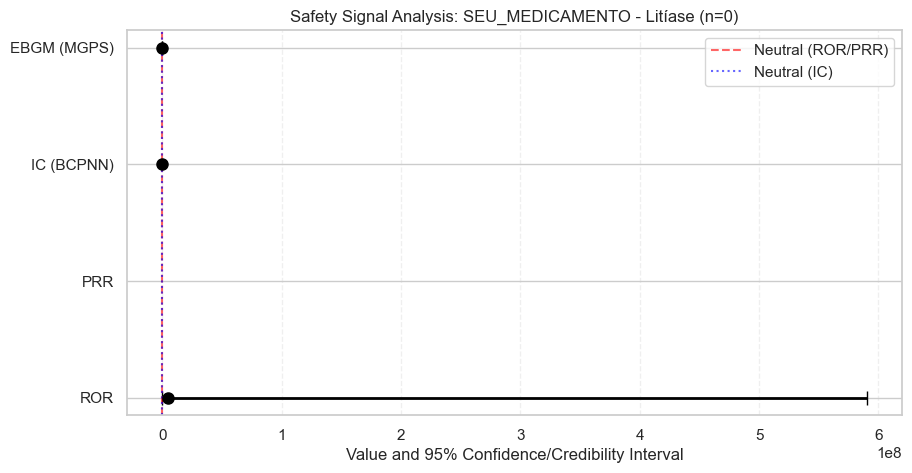

In [22]:
import matplotlib.pyplot as plt

# 1. PT: Execução da análise para o medicamento
#    EN: Running analysis for the drug studied in the paper
drug_ex = 'SEU_MEDICAMENTO' # Substitua pelo medicamento do seu interesse /Replace with the medication you are interested in.
event_ex = 'Litíase'     # Substitua pelo evento do seu interesse/ Replace with the medication you are interested in.

report, cases = analyze_safety_signal(df, 'drug', 'event', drug_ex, event_ex)

# 2. PT: Configuração do Gráfico / EN: Plot Configuration
plt.figure(figsize=(10, 5))
metrics = report['Metric']
values = report['Value']
low_ci = report['Value'] - report['Lower_CI']
high_ci = report['Upper_CI'] - report['Value']

plt.errorbar(values, metrics, xerr=[low_ci, high_ci], fmt='o', color='black',
             capsize=5, markersize=8, elinewidth=2)

# PT: Linhas de referência (1 para ROR/PRR, 0 para IC)
# EN: Reference lines (1 for ROR/PRR, 0 for IC)
plt.axvline(x=1, color='red', linestyle='--', alpha=0.6, label='Neutral (ROR/PRR)')
plt.axvline(x=0, color='blue', linestyle=':', alpha=0.6, label='Neutral (IC)')

plt.title(f'Safety Signal Analysis: {drug_ex} - {event_ex} (n={cases})')
plt.xlabel('Value and 95% Confidence/Credibility Interval')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

# 7️⃣ Exportação de Resultados / Exporting Results

**PT:** Esta etapa permite salvar as análises processadas em formatos acessíveis (CSV ou Excel) para uso em manuscritos ou relatórios técnicos.


---


**EN:** This step allows saving the processed analyses in accessible formats (CSV or Excel) for use in manuscripts or technical reports.

In [ ]:
# Exemplo de salvamento / Example of saving
# report_df.to_csv('resultado_sinal_seguranca.csv', index=False)

# 8️⃣ Conclusões e Limitações / Conclusions and Limitations

**PT:**

**Interpretação:** Um sinal de desproporcionalidade não estabelece causalidade; indica apenas uma associação estatística que requer avaliação clínica detalhada.


**Viés de Notificação:** Os resultados podem ser influenciados pelo viés de notificação (Efeito Weber, Under-reporting) inerente aos sistemas de vigilância passiva.


---


**EN:**

**Interpretation:** A disproportionality signal does not establish causality; it only indicates a statistical association that requires detailed clinical evaluation.

**Reporting Bias:** Results may be influenced by reporting bias (Weber Effect, Under-reporting) inherent in passive surveillance systems.

# 9️⃣ Referências / References


**PT:** Principais referências metodológicas utilizadas neste notebook.


---


**EN:** Main methodological references used in this notebook.



van Puijenbroek EP, Bate A, Leufkens HG, Lindquist M, Orre R, Egberts AC. A comparison of measures of disproportionality for signal detection in spontaneous reporting systems for adverse drug reactions. Pharmacoepidemiol Drug Saf. 2002;11(1):3-10.

Evans SJ, Waller PC, Davis S. Use of proportional reporting ratios (PRRs) for signal generation from spontaneous adverse drug reaction reports. Pharmacoepidemiol Drug Saf. 2001;10(6):483-6.

Bate A, Lindquist M, Edwards IR, et al. A Bayesian neural network method for adverse drug reaction signal generation. Eur J Clin Pharmacol. 1998;54(4):315-21.

DuMouchel W. Bayesian data mining in large frequency tables, with an application to the FDA Spontaneous Reporting System. Am Stat. 1999;53(3):177-90.

Jacoby C, et al. Vigimed – Banco padronizado de notificações de eventos adversos do Brasil. Harvard Dataverse. 2025. DOI: 10.xxxx/xxxxxx.